In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme(color_codes=True)

In [ ]:
file_path='/content/drive/MyDrive/flipkart_sales_enriched.csv'
df=pd.read_csv(file_path)
df

,Order ID,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Order Date,Payment Method,Customer Rating,Month,Year,Profit (INR),Discount %,Customer Segment,Region
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5,September,2024,19627.824,11,Online,West
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9,December,2024,10204.680,24,Wholesale,North
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4,May,2024,8873.752,19,Online,South
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2,November,2024,6531.562,15,Online,North
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1,December,2024,15954.048,12,Retail,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD00996,Smartphone,Electronics,28995.81,3,86987.43,2025-01-13,COD,5.0,January,2025,17397.486,28,Wholesale,West
996,ORD00997,Perfume,Beauty,32799.51,2,65599.02,2024-12-18,Wallet,2.4,December,2024,13119.804,23,Wholesale,North
997,ORD00998,Face Cream,Beauty,40840.80,1,40840.80,2024-07-26,UPI,3.1,July,2024,8168.160,11,Retail,West
998,ORD00999,Cookware Set,Home & Kitchen,34741.79,4,138967.16,2024-10-02,Net Banking,3.2,October,2024,27793.432,7,Wholesale,East


In [ ]:
df2 = df.drop(columns=['Order ID','Order Date','Payment Method','Region'], errors='ignore')
df2

,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Customer Rating,Month,Year,Profit (INR),Discount %,Customer Segment
0,Educational Book,Books,49069.56,2,98139.12,3.5,September,2024,19627.824,11,Online
1,Jeans,Clothing,12755.85,4,51023.40,3.9,December,2024,10204.680,24,Wholesale
2,Face Cream,Beauty,11092.19,4,44368.76,4.4,May,2024,8873.752,19,Online
3,Smartwatch,Electronics,32657.81,1,32657.81,3.2,November,2024,6531.562,15,Online
4,Cookware Set,Home & Kitchen,26590.08,3,79770.24,3.1,December,2024,15954.048,12,Retail
...,...,...,...,...,...,...,...,...,...,...,...
995,Smartphone,Electronics,28995.81,3,86987.43,5.0,January,2025,17397.486,28,Wholesale
996,Perfume,Beauty,32799.51,2,65599.02,2.4,December,2024,13119.804,23,Wholesale
997,Face Cream,Beauty,40840.80,1,40840.80,3.1,July,2024,8168.160,11,Retail
998,Cookware Set,Home & Kitchen,34741.79,4,138967.16,3.2,October,2024,27793.432,7,Wholesale


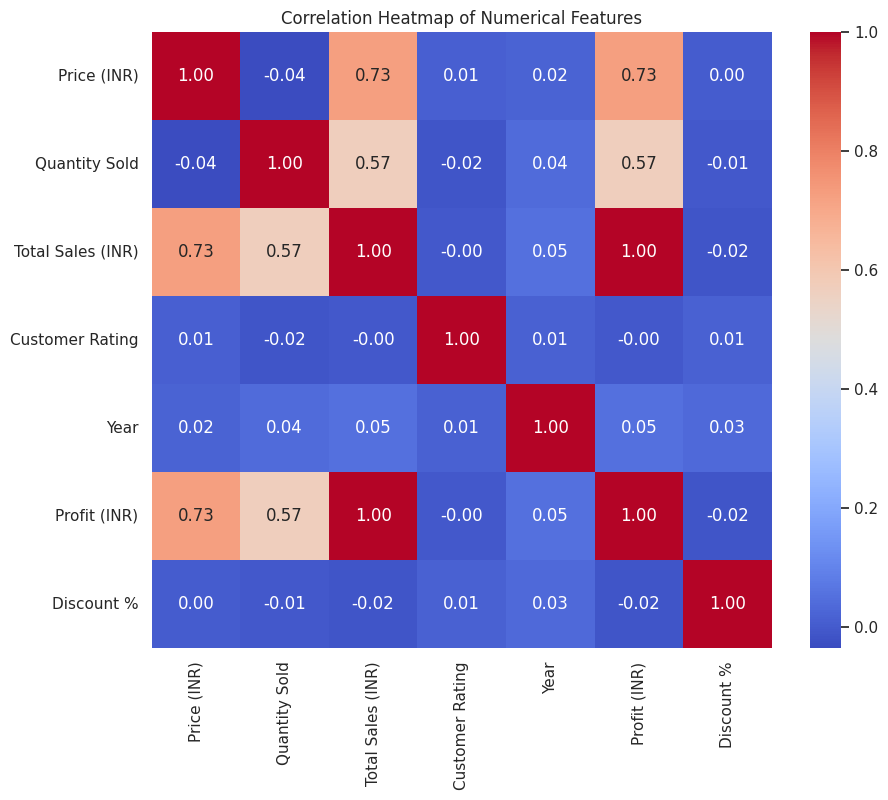

In [ ]:
numerical_cols = df2.select_dtypes(include=np.number).columns
correlation_matrix = df2[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

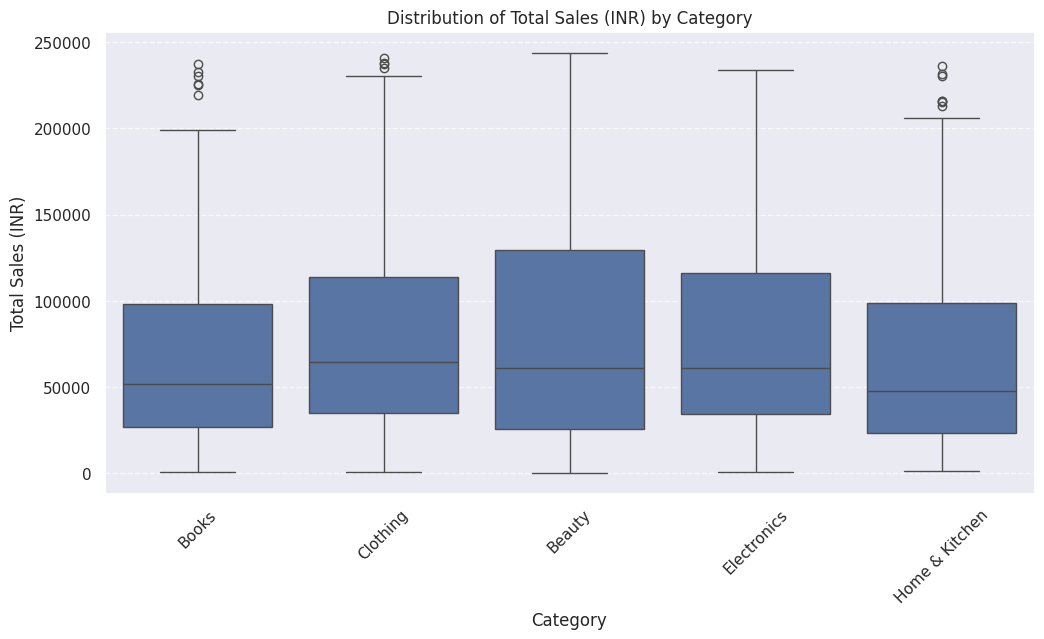

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='Total Sales (INR)', data=df2)
plt.title('Distribution of Total Sales (INR) by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales (INR)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_927/840930190.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Total Sales (INR)', data=category_sales, palette='viridis')


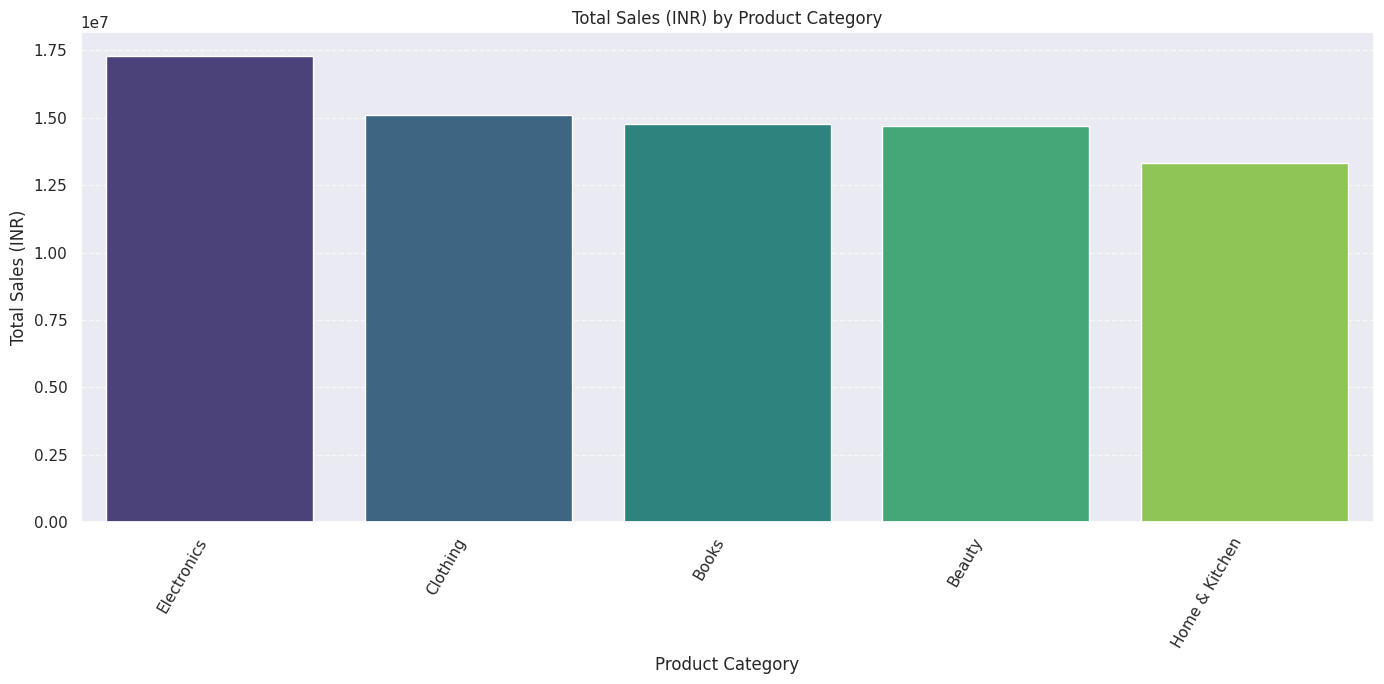

In [ ]:
category_sales = df2.groupby('Category')['Total Sales (INR)'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='Category', y='Total Sales (INR)', data=category_sales, palette='viridis')
plt.title('Total Sales (INR) by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (INR)')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### XGBoost Regressor Model

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# Define features (X) and target (y)
X = df2.drop('Total Sales (INR)', axis=1)
y = df2['Total Sales (INR)']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a pipeline with preprocessing and XGBoost Regressor
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(random_state=42))])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preparation complete. X_train and X_test are ready for training.")

Data preparation complete. X_train and X_test are ready for training.


Now, let's train the XGBoost Regressor model on the prepared training data.

In [ ]:
# Train the XGBoost Regressor model
model_pipeline.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully!")

XGBoost Regressor model trained successfully!


Next, we will evaluate the trained model's performance on the test set using metrics like R-squared and Mean Squared Error.

In [ ]:
# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 841653.16
R-squared: 1.00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df2.drop('Total Sales (INR)', axis=1)
y = df2['Total Sales (INR)']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

# Create a Random Forest Regressor model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model.fit(X_train, y_train)

print('Random Forest Regressor trained successfully!')

Random Forest Regressor trained successfully!


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R2): {r2:.2f}')



Mean Absolute Error (MAE): 222.66
Mean Squared Error (MSE): 150110.84
R-squared (R2): 1.00


### Search for Products by Name

Use the cell below to enter a product name and display all matching records from the dataset.

In [ ]:
# Prompt the user for a product name
product_name_to_search = input("Enter the product name to search for: ")

# Filter the DataFrame based on the product name (case-insensitive search)
matching_products = df2[df2['Product Name'].str.contains(product_name_to_search, case=False, na=False)]

# Display the matching products
if not matching_products.empty:
    print(f"\nFound {len(matching_products)} products matching '{product_name_to_search}':")
    display(matching_products)
else:
    print(f"\nNo products found matching '{product_name_to_search}'. Please check the spelling.")

Enter the product name to search for: headphone

Found 44 products matching 'headphone':


,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Customer Rating,Month,Year,Profit (INR),Discount %,Customer Segment
41,Headphones,Electronics,965.51,4,3862.04,3.5,June,2024,772.408,29,Wholesale
58,Headphones,Electronics,38476.48,4,153905.92,2.0,August,2024,30781.184,6,Online
77,Headphones,Electronics,34161.44,1,34161.44,2.4,June,2024,6832.288,26,Retail
83,Headphones,Electronics,28892.73,4,115570.92,1.3,November,2024,23114.184,8,Wholesale
94,Headphones,Electronics,12506.31,3,37518.93,1.4,January,2025,7503.786,17,Retail
121,Headphones,Electronics,28688.25,3,86064.75,2.4,May,2024,17212.950,9,Retail
123,Headphones,Electronics,24500.05,3,73500.15,4.4,April,2024,14700.030,11,Retail
218,Headphones,Electronics,39749.19,1,39749.19,3.5,July,2024,7949.838,11,Online
229,Headphones,Electronics,41742.29,5,208711.45,2.6,July,2024,41742.290,26,Online
234,Headphones,Electronics,42981.89,5,214909.45,1.8,January,2025,42981.890,23,Online


### Predict Total Sales with Partial Input

This section allows you to predict total sales by providing only the product name, quantity, and category. The remaining features will be estimated using the average or most frequent values from your dataset.

In [ ]:
# Prompt the user for input
product_name_input = input("Enter Product Name: ")
quantity_input = int(input("Enter Quantity Sold: "))
category_input = input("Enter Category: ")

# Prepare default values for other features
# Use descriptive statistics from df2 for numeric columns
default_price = df2['Price (INR)'].mean()
default_customer_rating = df2['Customer Rating'].mean()
default_profit = df2['Profit (INR)'].mean()
default_discount = df2['Discount %'].mean()

# Use mode for categorical/date-related columns
default_month = df2['Month'].mode()[0]
default_year = df2['Year'].mode()[0]
default_customer_segment = df2['Customer Segment'].mode()[0]

# Create a dictionary with user inputs and default values
prediction_input = {
    'Product Name': product_name_input,
    'Category': category_input,
    'Price (INR)': default_price, # Using default
    'Quantity Sold': quantity_input,
    'Customer Rating': default_customer_rating, # Using default
    'Month': default_month, # Using default
    'Year': default_year, # Using default
    'Profit (INR)': default_profit, # Using default
    'Discount %': default_discount, # Using default
    'Customer Segment': default_customer_segment # Using default
}

# Convert to DataFrame, ensuring correct column order as per original X
# It's crucial that the order of columns matches the training data.
input_df = pd.DataFrame([prediction_input])

# Make prediction
predicted_sale = model.predict(input_df)

print(f"\nPredicted Total Sale for '{product_name_input}' ({quantity_input} units) in '{category_input}': {predicted_sale[0]:.2f} INR")

Enter Product Name: headphone
Enter Quantity Sold: 2
Enter Category: Electronics

Predicted Total Sale for 'headphone' (2 units) in 'Electronics': 75291.22 INR
